<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/Bootstrap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  <span style="color:magenta;">**Bootstrap**</span>

<span style="color:teal;">**Nombre:** </span> Jerónimo López Annette Michelle

<span style="color:teal;"> **Objetivo:**</span> Aplicar la técnica de Bootstrap para estimar la distribución muestral de la media de los tiempos de entrega a partir de una muestra de 12 observaciones. Mediante la generación de 1000 muestras con reemplazo, se busca obtener una estimación del error estándar de la media y construir un intervalo de confianza del 95%, sin asumir una distribución teórica específica para los datos.

Suponga que $X_1,...,X_n$ son variables aleatorias independientes con una función de distribución común F. Queremos estimar $θ(F)$ mediante el estimador $g(X_1,...,X_n)$. Entonces

$$
  ECM(F)=E_F [(g(X_1,...,X_n)-θ(F))^2]
$$

Estimaremos F con:

$$
F_e(x)=\frac{número \quad de \quad i: \quad X_i ≤x}{n}
$$
Distribución empiríca

<span style="color:teal;">**Ejemplo:**</span> Esta es una muestra aleatoria de 12 tiempos de entrega;

$$
35,42,38,40,45,37,39,41,44,36,43,40
$$

**Instrucciones:**

1. Use la muestra original de 12 observaciones y genere $1000$ muestras Bootstra.

2. Para cada muestr B calcule la media.

3. Al final:
* Obtenga la media de las $1000$ muestras.
* Clacule la desviación estándar.
* Determine los porcentiles $2.5\%$ y $97.5\%$ para construir el  intervalo de confianza $B$ del $95\%$

In [31]:
# Importamos las librerias
import numpy as np
import matplotlib.pyplot as plt
import random as r

Tomando los datos de la muestra:

In [32]:
#datos de la amuestra los cuales son 12 datos:  tiempos de entrega
datos = np.array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])
datos

array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])

In [33]:
# Número de réplicas Bootstrap
B = 1000
# Tamaño de la muestra original
n = len(datos)

In [34]:
n

12

Generamos la muestras de BOOTSTRAP y calculamos su media para ello su probabilidad ser de
$$\frac{\# \quad veces \quad que \quad se \quad repite \quad un \quad número \quad de \quad la \quad muestra}{12}$$

In [35]:
# Lista donde se almacenarán las medias Bootstrap
medias_bootstrap = []

for i in range(B):

    # Se genera una muestra de tamaño n
    # utilizando muestreo con reemplazo
    muestra_bootstrap = np.random.choice(
        datos,
        size=n,
        replace=True
    )

    # Cálculo de la media de la muestra Bootstrap
    media_muestra = np.mean(muestra_bootstrap)

    # Almacenamiento de la media
    medias_bootstrap.append(media_muestra)

# Convertimos la lista en arreglo NumPy
medias_bootstrap = np.array(medias_bootstrap)


Calculamos los estadísticos para BOOTSTRAP dada por las expresiones:

$$
  ECM(F)=E_F [(g(X_1,...,X_n)-θ(F))^2]
$$

Estimaremos F con:

$$
F_e(x)=\frac{número \quad de \quad i: \quad X_i ≤x}{n}
$$

In [36]:
# Media de las 1000 medias Bootstrap
media_boot = np.mean(medias_bootstrap)

In [37]:
media_boot

np.float64(39.95125)

In [38]:
# Desviación estándar Bootstrap
error_boot = np.std(
    medias_bootstrap,
    ddof=1
)

In [39]:
error_boot

np.float64(0.8897282971962398)

In [40]:
# Percentiles para el IC Bootstrap del 95%
p2_5 = np.percentile(medias_bootstrap, 2.5)
p97_5 = np.percentile(medias_bootstrap, 97.5)

Resultados del Método de Bootstarp:

In [41]:
print("RESULTADOS DEL MÉTODO BOOTSTRAP")
print("=" * 50)

print(f"Tamaño de muestra (n): {n}")
print(f"Número de réplicas Bootstrap (B): {B}")

print("\nEstadísticos Bootstrap")
print("-" * 50)

print(f"Media Bootstrap: {media_boot:.4f}")
print(f"Desviación estándar Bootstrap: {error_boot:.4f}")

print("\nIntervalo de confianza Bootstrap (95%)")
print("-" * 50)

print(f"Percentil 2.5%  : {p2_5:.4f}")
print(f"Percentil 97.5% : {p97_5:.4f}")

print(
    f"\nIC Bootstrap 95% = "
    f"[{p2_5:.4f}, {p97_5:.4f}]"
)


RESULTADOS DEL MÉTODO BOOTSTRAP
Tamaño de muestra (n): 12
Número de réplicas Bootstrap (B): 1000

Estadísticos Bootstrap
--------------------------------------------------
Media Bootstrap: 39.9513
Desviación estándar Bootstrap: 0.8897

Intervalo de confianza Bootstrap (95%)
--------------------------------------------------
Percentil 2.5%  : 38.1667
Percentil 97.5% : 41.7500

IC Bootstrap 95% = [38.1667, 41.7500]


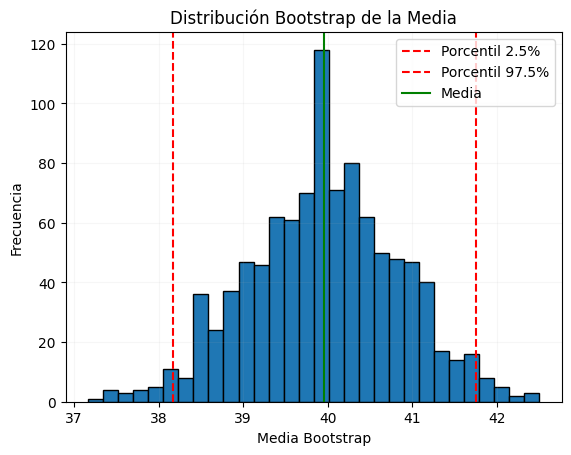

In [42]:
plt.hist(medias_bootstrap, bins=30, edgecolor='black')
plt.axvline(p2_5, color='red', linestyle='--', label='Porcentil 2.5%')
plt.axvline(p97_5, color='red', linestyle='--', label='Porcentil 97.5%')
plt.axvline(media_boot, color='green', linestyle='-', label='Media')
plt.title('Distribución Bootstrap de la Media')
plt.xlabel('Media Bootstrap')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.1)
plt.show()

### <span style="color:teal;"> **Solución Analítica** </span>

Veamos la solución analítica dada la muestra aleatoria de 12 tiempos de entrega;

$$
35,42,38,40,45,37,39,41,44,36,43,40
$$

Primero calculamos el promedio de la muestra observada:

$$
\bar{x}=\frac{1}{12}\sum_{i=1}^{12} x_i=\frac{35+42+38+40+45+37+39+41+44+36+43+40}{12}
$$

$$
\bar{x}=40.
$$

En el procedimiento Bootstrap, cada dato de la muestra original tiene la misma probabilidad de ser seleccionado en una remuestra. Por ello,

$$
P(X^{*}=x_i)=\frac{1}{12},
\qquad i=1,\ldots,12.
$$

La esperanza de la distribución empírica Bootstrap coincide con la media muestral:

$$
E(X^{*})=\sum_{i=1}^{12}x_i,P(X^{*}=x_i)= \frac{1}{12}\sum_{i=1}^{12}x_i=40
$$

Para obtener la variabilidad de la distribución empírica, se calculan primero las desviaciones cuadráticas respecto a la media:

$$
\sum_{i=1}^{12}(x_i-\bar{x})^2=25+4+4+0+25+9+1+1+16+16+9+0=110.
$$

De esta forma, la varianza asociada a una observación Bootstrap es

$$
\mathrm{Var}(X^{*})=\frac{110}{12}=9.1667.
$$

Sea ahora

$$
\bar{X}^{*}=\frac{1}{12}\sum_{j=1}^{12}X_j^{*}
$$

la media obtenida a partir de una remuestra Bootstrap. Su valor esperado es

$$
E(\bar{X}^{*})=40.
$$

Además, como las observaciones remuestreadas son independientes,

$$
\mathrm{Var}(\bar{X}^{*})= \frac{\mathrm{Var}(X^{*})}{12} \frac{9.1667}{12}=
0.7639.
$$

La desviación estándar de la media Bootstrap resulta

$$
\sigma_{\bar{X}^{*}}=\sqrt{0.7639}\approx 0.874.
$$

Utilizando una aproximación normal, el intervalo de confianza bilateral del $95\%$ para la media se construye mediante

$$
\bar{x} \pm z_{0.975},\sigma_{\bar{X}^{*}},
$$

donde $z_{0.975}=1.96$.

Sustituyendo los valores obtenidos:

$$
40 \pm 1.96(0.874)= 40 \pm 1.713.
$$

Por lo tanto el intervalo de confianza ,

$$
IC_{95\%}=(38.287,;41.713).
$$

En resumen,

$$
E(\bar{X}^{*})=40,
$$

$$
\sigma_{\bar{X}^{*}}\approx 0.874,
$$

y

$$
IC_{95\%} \approx (38.29,;41.71).
$$

Observemos que el error es casi nulo dado a que tuvimos una buena aproximación


# <span style="color:teal;"> **Conclusión** </span>

La técnica Bootstrap permitió aproximar la variabilidad de la media utilizando únicamente la información contenida en la muestra original. A partir de las $1000$ réplicas generadas, se obtuvo una distribución empírica de las medias, lo que facilitó el cálculo de la media Bootstrap, su desviación estándar y el intervalo de confianza del $95\%$.

Este método resulta especialmente útil cuando se desconoce la distribución poblacional o cuando el tamaño de muestra es reducido, ya que proporciona estimaciones confiables basadas en remuestreo. En este caso, el intervalo de confianza obtenido ofrece un rango plausible para la media poblacional de los tiempos de entrega, permitiendo evaluar la precisión del estimador y la incertidumbre asociada a la estimación.